# IEA-22-280-RWT windIO blade → OpenSG → full Timoshenko 6×6

This tutorial runs the pipeline **from scratch**: it reads the source **windIO** blade file — the
`IEA-22-280-RWT` reference turbine, taken from the [windIO](https://github.com/IEAWindSystems/windIO)
repository's `examples/turbine/` (bundled here under `examples/data/windio/`) — and converts it to the
OpenSG 1-D shell cross-section with the vendored
**[OpenSG_io](https://github.com/bagla0/OpenSG_io)** converter in `third_party/OpenSG_io` (no pre-generated
YAML).

## 1 · windIO → OpenSG cross-section (run live)

`load_blade` → `build_cross_section(r=0.5)` → `emit_opensg_yaml` produces the 1-D shell SG YAML below. The
2-D solid SG YAML is meshed from the same station by **PreVABS** (`emit_prevabs` → `prevabs --vabs --hm` →
`convert_sg_to_yaml`); that binary step is committed, so the solid and VABS reference are loaded from
`examples/data/`.

In [1]:
import os, sys, time
import numpy as np
def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("OpenSG-TW repo root not found - run this notebook from inside the cloned repo")
        d = parent
CC = _find_repo_root()
for p in ("", "opensg_jax"):
    sys.path.insert(0, os.path.join(CC, p))
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import jax; jax.config.update("jax_enable_x64", True)
np.set_printoptions(precision=4, linewidth=160, suppress=True)
from IPython.display import Image
from fe_jax.orient_plot import plot_orient
from opensg_jax.fe_jax.timo_report import (sym, pcterr, full_pcterr, diag_table, term_table,
                                          compare_terms, print_6x6, nonzero_terms, parse_vabs, wall_t, LBL)
print("ready | jax", jax.__version__)

ready | jax 0.9.2


In [2]:
# --- windIO -> OpenSG 1-D shell SG YAML, generated live from scratch via the vendored OpenSG_io ---
sys.path.insert(0, os.path.join(CC, "third_party", "OpenSG_io"))
from opensg_io import load_blade, build_cross_section, emit_opensg_yaml
WINDIO = os.path.join(CC, "examples", "data", "windio", "IEA-22-280-RWT.yaml")   # IEA-22-280-RWT, from the windIO repo (examples/turbine/)
GEN = os.path.join(CC, "docs", "tutorials", "_gen"); os.makedirs(GEN, exist_ok=True)
blade = load_blade(WINDIO)                                    # windIO v2 blade reader
cs = build_cross_section(blade, r=0.5, mesh_size=0.01)        # resolve laminates + webs at r/R = 0.5
SHELL = os.path.join(GEN, "iea22_r050_shell.yaml")
emit_opensg_yaml(cs, SHELL)                                   # OUTPUT 1: 1-D shell SG YAML (just generated)
import yaml as _yaml
_d = _yaml.safe_load(open(SHELL))
print("from scratch:", os.path.basename(WINDIO), "-> shell", len(_d["elements"]), "elems,",
      len(_d["sets"]["element"]), "laminates  (chord %.3f m)" % cs["chord"])
# OUTPUT 2: the 2-D solid is meshed by PreVABS from emit_prevabs(cs, ...) -> .xml -> prevabs --vabs --hm ->
# convert_sg_to_yaml.py.  That binary step is committed, so the solid + VABS reference are loaded here:
SOLIDY = os.path.join(CC, "examples", "data", "2d_yaml", "iea22_r050_solid.yaml")
KFILE  = os.path.join(CC, "examples", "data", "benchmark", "iea22_r050.sg.K")
print("2-D solid (PreVABS-meshed):", os.path.basename(SOLIDY), "| VABS ref:", os.path.basename(KFILE))

from scratch: IEA-22-280-RWT.yaml -> shell 277 elems, 6 laminates  (chord 4.861 m)
2-D solid (PreVABS-meshed): iea22_r050_solid.yaml | VABS ref: iea22_r050.sg.K


## 2 · Material orientation (solid + shell)

[orient_plot] SHELL: e3 OML->IML 216/277   e1_z mean=1.000


[orient_plot] SOLID: e3 OML->IML 446/461   e1_z mean=1.000


[orient_plot] wrote _img/iea22_orient.png


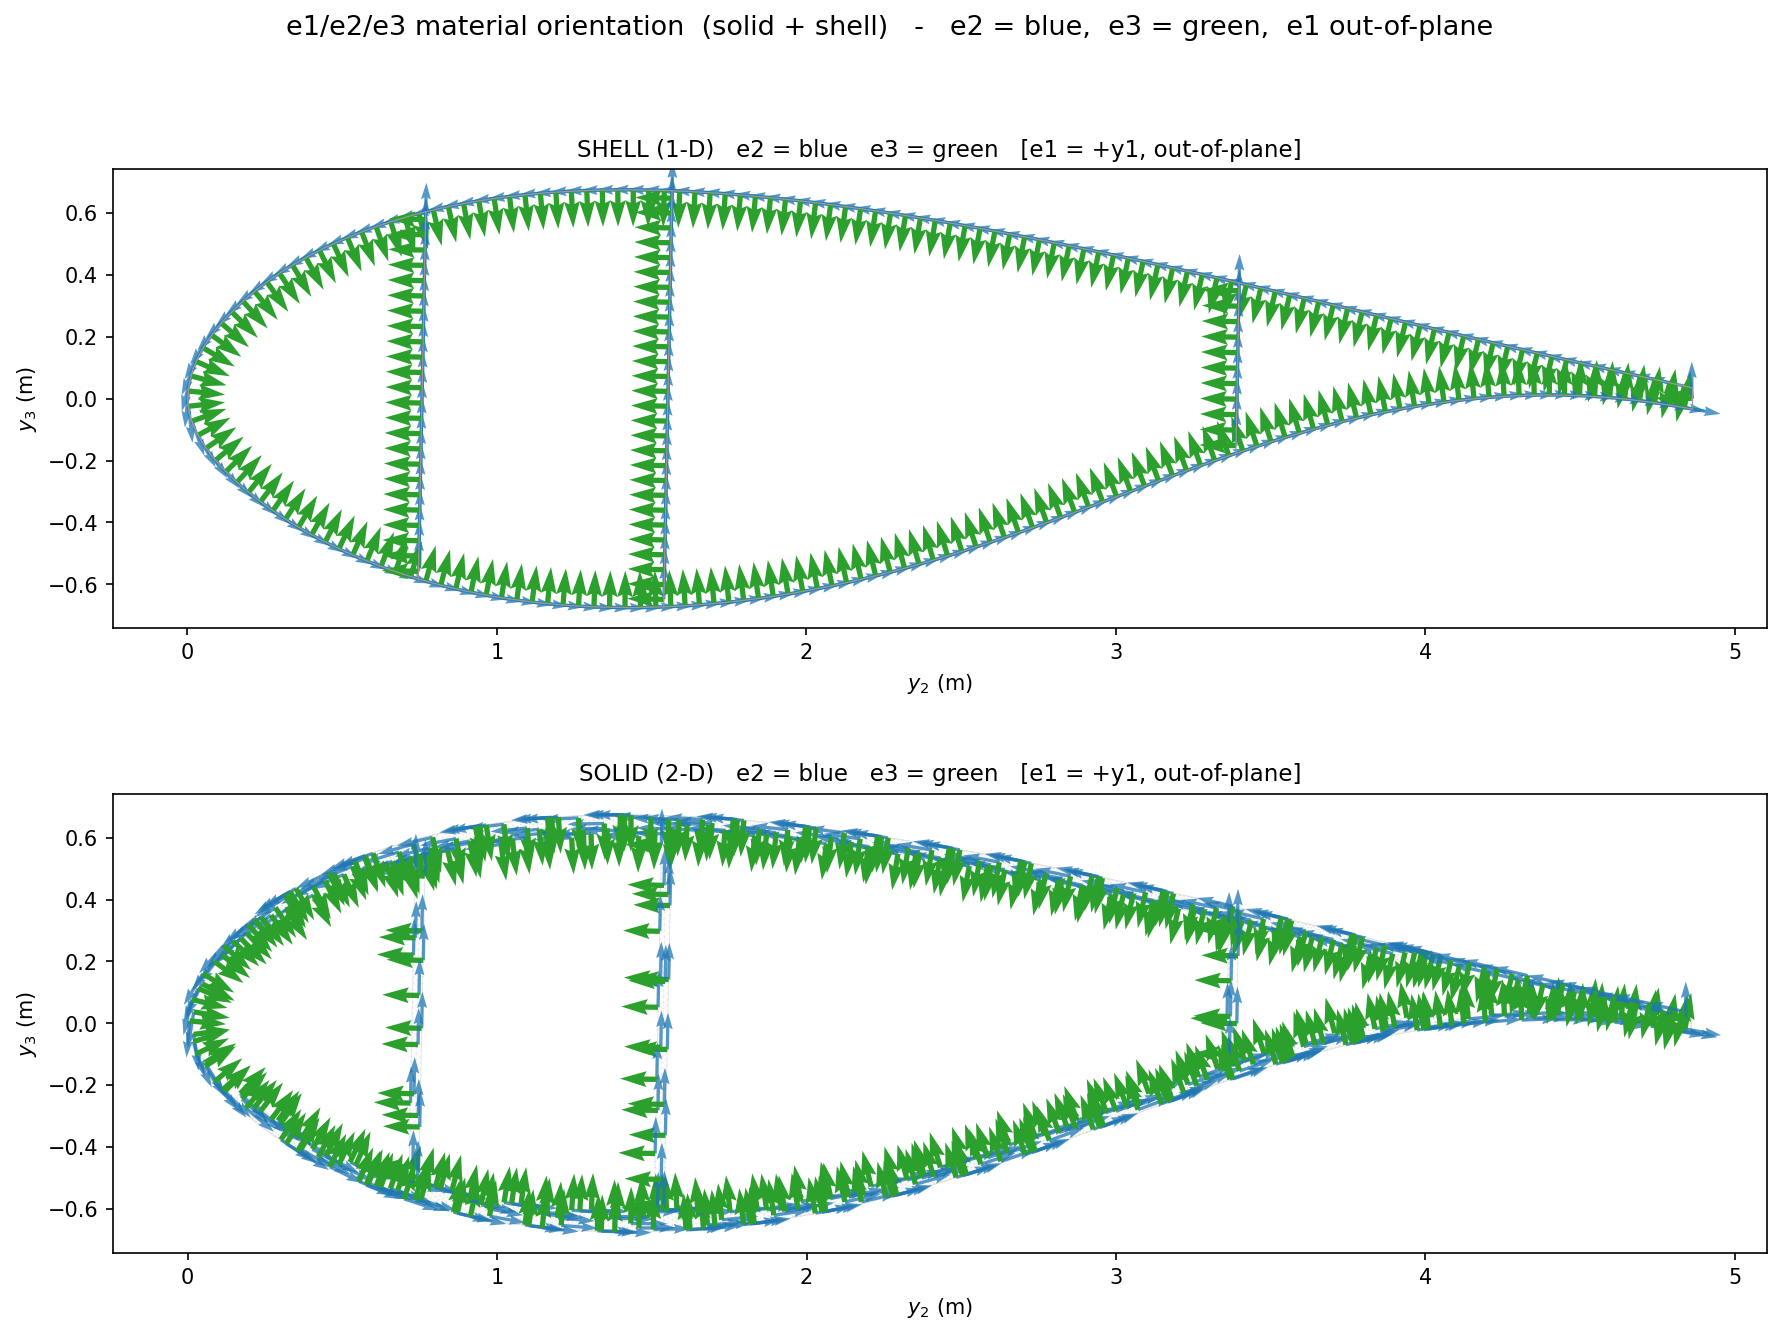

In [3]:
png = plot_orient(SHELL, SOLIDY, out_png=os.path.join(os.path.join(CC, "docs", "tutorials", "_img"), "iea22_orient.png"))
Image(filename=png)

## 3 · Full Timoshenko 6×6 — JAX 2-D solid vs VABS

The benchmark `iea22_r050.sg.K` is the **VABS** Timoshenko stiffness for this station, run on the same
`iea22_r050.sg` mesh that `solid_iea22_r050.yaml` was generated from — so this is the exact, no-compromise
reference (order `[EA, GA2, GA3, GJ, EI2, EI3]`).

In [4]:
from opensg_jax.fe_jax.solid_timo import compute_timo_from_yaml
t0 = time.time()
C6 = sym(compute_timo_from_yaml(SOLIDY, verbose=False))
print("solid solve: %.1f s\n" % (time.time() - t0))
print("JAX 2-D solid Timoshenko 6x6  [EA, GA2, GA3, GJ, EI2, EI3]:")
print(C6)
V = sym(parse_vabs(KFILE))               # VABS .K reference
print("\nVABS .K Timoshenko 6x6:")
print(V)
print()
term_table("JAX-solid", C6, V)
print("\nFull 6x6 %-error vs VABS (terms >=1000x below max neglected -> 0):")
print(pcterr(C6, V))
thr = np.max(np.abs(V)) / 1000.0
worst = max(abs(100*(C6[i,j]-V[i,j])/V[i,j]) for i in range(6) for j in range(6) if abs(V[i,j])>=thr)
print("\nworst kept term (|VABS| >= max/1000) : %.4f %%" % worst)

solid solve: 13.2 s

JAX 2-D solid Timoshenko 6x6  [EA, GA2, GA3, GJ, EI2, EI3]:
[[ 2.1149e+10  0.0000e+00  0.0000e+00  0.0000e+00  1.8524e+08 -3.0480e+10]
 [ 0.0000e+00  5.1583e+08  5.4435e+06 -1.3773e+07  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  5.4435e+06  2.0408e+08  2.3329e+08  0.0000e+00  0.0000e+00]
 [ 0.0000e+00 -1.3773e+07  2.3329e+08  7.3514e+08  0.0000e+00  0.0000e+00]
 [ 1.8524e+08  0.0000e+00  0.0000e+00  0.0000e+00  7.1146e+09 -5.1818e+08]
 [-3.0480e+10  0.0000e+00  0.0000e+00  0.0000e+00 -5.1818e+08  6.2597e+10]]

VABS .K Timoshenko 6x6:
[[ 2.1149e+10  0.0000e+00  0.0000e+00  0.0000e+00  1.8524e+08 -3.0480e+10]
 [ 0.0000e+00  5.1584e+08  5.4433e+06 -1.3775e+07  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  5.4433e+06  2.0408e+08  2.3329e+08  0.0000e+00  0.0000e+00]
 [ 0.0000e+00 -1.3775e+07  2.3329e+08  7.3515e+08  0.0000e+00  0.0000e+00]
 [ 1.8524e+08  0.0000e+00  0.0000e+00  0.0000e+00  7.1146e+09 -5.1819e+08]
 [-3.0480e+10  0.0000e+00  0.0000e+00  0.0000e+00 -5.1819e+08  6.259

## 4 · RM shell (from the 1-D shell YAML)

The reduced RM shell model runs straight off the 1-D shell YAML and is benchmarked against the same
2-D solid result — the thin-walled reduction for the same station.

In [5]:
from opensg_jax.fe_jax.strip_RM import rm_timoshenko_6x6
from opensg_jax.fe_jax.gradient_kirchhoff import gradient_junction_kirchhoff
T = wall_t(SHELL)
C_rm = sym(rm_timoshenko_6x6(SHELL, 0.0, dshift=T/2, curved=False, shear="mitc"))
C_kl = sym(gradient_junction_kirchhoff(SHELL, frac=0.0, dshift=T/2)[0])
print_6x6(C_rm, "RM (1-D shell)"); print()
print_6x6(C_kl, "KL (1-D shell)")
print("\nRM and KL vs the JAX 2-D solid - % diff on every non-zero Cij term:")
compare_terms(C6, {"RM": C_rm, "KL": C_kl})

[orient_plot] SHELL: e3 OML->IML 216/277   e1_z mean=1.000


[orient_plot] wrote _gen/iea22_r050_shell_orient_e1e2e3.png


RM (1-D shell) Timoshenko 6x6  [EA, GA2, GA3, GJ, EI2, EI3]:
    2.18465e+10   0.00000e+00   0.00000e+00   0.00000e+00   2.53050e+08  -3.11213e+10
    0.00000e+00   5.35949e+08   5.96378e+06  -1.44529e+07   0.00000e+00   0.00000e+00
    0.00000e+00   5.96378e+06   1.99351e+08   2.33769e+08   0.00000e+00   0.00000e+00
    0.00000e+00  -1.44529e+07   2.33769e+08   7.69055e+08   0.00000e+00   0.00000e+00
    2.53050e+08   0.00000e+00   0.00000e+00   0.00000e+00   7.60231e+09  -5.79360e+08
   -3.11213e+10   0.00000e+00   0.00000e+00   0.00000e+00  -5.79360e+08   6.29579e+10

KL (1-D shell) Timoshenko 6x6  [EA, GA2, GA3, GJ, EI2, EI3]:
    2.18467e+10  -1.41598e+03   5.44176e+02   6.93774e+02   2.53067e+08  -3.11215e+10
   -1.41598e+03   5.37616e+08   5.97065e+06  -1.45257e+07  -3.14588e+03   2.52780e+03
    5.44176e+02   5.97065e+06   2.00154e+08   2.34095e+08  -3.83390e+03   3.93117e+03
    6.93774e+02  -1.45257e+07   2.34095e+08   7.71065e+08  -4.36271e+03   4.50133e+03
    2.53067e+08  

{'RM': np.float64(36.61012090389271), 'KL': np.float64(36.6191689848469)}

## Takeaway

From a single **windIO** file, OpenSG_io emits the OpenSG cross-section YAMLs, and OpenSG-TW returns the
**full $6\times6$ Timoshenko** stiffness — the JAX 2-D solid matching VABS, and the reduced RM shell
bracketing it from the 1-D YAML. Repeat at every span station to build the blade's 1-D beam model.